**Part 4: Investigating Prediction Failures**

Overview of the five largest errors

Of the five worst predictions, three were over-predictions (model predicted a higher price than the property actually sold for: P0104, P0001, P0106) and two were under-predictions (P0008, P0002). Errors ranged from `$977k` to `$1.35M`, representing 33.5%–80.9% of the actual sale price — substantial misses that suggest the model is missing something structural, not just noise.

property_id                                     address      suburb  bedrooms  bathrooms  parking  land_size_sqm sale_price predicted_price       error  abs_error pct_error
      P0104 90 Josephine Crescent, Cherrybrook NSW 2126 Cherrybrook         4          2        2          893.0 $1,666,000      $3,013,947  $1,347,947 $1,347,947     80.9%
      P0001     103 Halcyon Avenue, Kellyville NSW 2155  Kellyville         5          3        2          502.0 $1,521,000      $2,661,077  $1,140,077 $1,140,077     75.0%
      P0008         36 Avril Court, Kellyville NSW 2155  Kellyville         4          2        2          505.0 $3,195,000      $2,076,635 $-1,118,365 $1,118,365    -35.0%
      P0106       42 Pogson Drive, Cherrybrook NSW 2126 Cherrybrook         4          3        2          942.0 $1,914,000      $2,895,072    $981,072   $981,072     51.3%
      P0002        75 Aruma Avenue, Kellyville NSW 2155  Kellyville         3          2        1          743.0 $2,915,000      $1,937

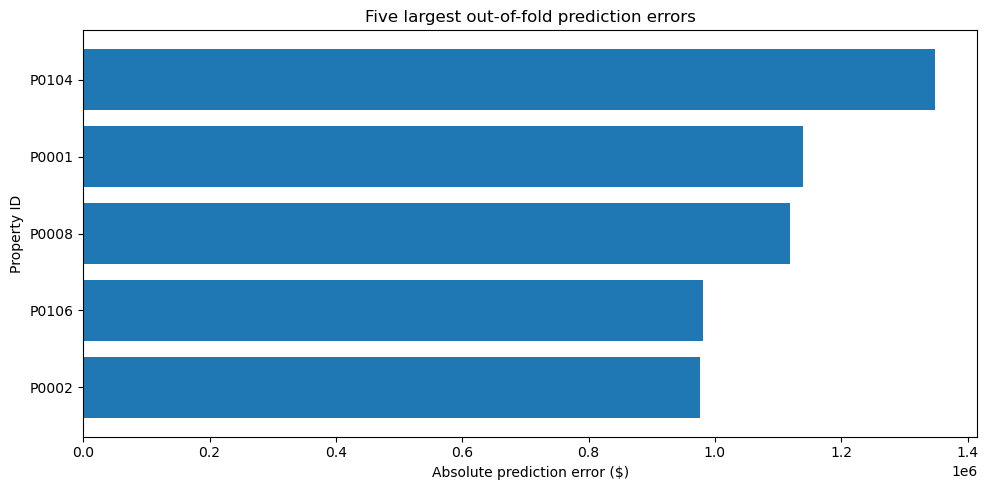


 P0104 90 Josephine Crescent, Cherrybrook NSW 2126
Actual: $1,666,000
Predicted: $3,013,947
Absolute error: $1,347,947
Percentage error: 80.9%
Comparable-property median: $2,825,000 | n = 14

 P0001 103 Halcyon Avenue, Kellyville NSW 2155
Actual: $1,521,000
Predicted: $2,661,077
Absolute error: $1,140,077
Percentage error: 75.0%
No close comparable properties found in the sample.

 P0008 36 Avril Court, Kellyville NSW 2155
Actual: $3,195,000
Predicted: $2,076,635
Absolute error: $1,118,365
Percentage error: -35.0%
Comparable-property median: $2,180,000 | n = 20

 P0106 42 Pogson Drive, Cherrybrook NSW 2126
Actual: $1,914,000
Predicted: $2,895,072
Absolute error: $981,072
Percentage error: 51.3%
Comparable-property median: $3,020,000 | n = 15

 P0002 75 Aruma Avenue, Kellyville NSW 2155
Actual: $2,915,000
Predicted: $1,937,914
Absolute error: $977,086
Percentage error: -33.5%
Comparable-property median: $2,509,000 | n = 3


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("oof_predictions.csv")

# Largest errors in dollar terms
top5 = results.nlargest(5, "abs_error").copy()

table = top5[
    ["property_id", "address", "suburb", "bedrooms", "bathrooms",
     "parking", "land_size_sqm", "sale_price", "predicted_price",
     "error", "abs_error", "pct_error"]
].copy()
for col in ["sale_price", "predicted_price", "error", "abs_error"]:
    table[col] = table[col].map(lambda v: f"${v:,.0f}")
table["pct_error"] = top5["pct_error"].map(lambda v: f"{v:.1f}%")
print(table.to_string(index=False))

# Visualise the five largest errors
plot_df = top5.sort_values("abs_error")
plt.figure(figsize=(10, 5))
plt.barh(plot_df["property_id"], plot_df["abs_error"])
plt.xlabel("Absolute prediction error ($)")
plt.ylabel("Property ID")
plt.title("Five largest out-of-fold prediction errors")
plt.tight_layout()
plt.savefig("part4_largest_errors.png", dpi=150)
plt.show()

# Check whether the largest errors are unusual within their suburb
for _, row in top5.iterrows():
    peers = results[
        (results["suburb"] == row["suburb"]) &
        (results["property_id"] != row["property_id"]) &
        (results["bedrooms"] == row["bedrooms"]) &
        (results["bathrooms"] == row["bathrooms"])
    ].copy()

    if pd.notna(row["land_size_sqm"]):
        peers = peers[
            peers["land_size_sqm"].between(
                row["land_size_sqm"] - 100,
                row["land_size_sqm"] + 100
            )
        ]

    print("\n", row["property_id"], row["address"])
    print("Actual:", f"${row['sale_price']:,.0f}")
    print("Predicted:", f"${row['predicted_price']:,.0f}")
    print("Absolute error:", f"${row['abs_error']:,.0f}")
    print("Percentage error:", f"{row['pct_error']:.1f}%")
    if len(peers):
        print("Comparable-property median:",
              f"${peers['sale_price'].median():,.0f}",
              "| n =", len(peers))
    else:
        print("No close comparable properties found in the sample.")


**Case-by-case discussion**

- P0104 — 90 Josephine Crescent, Cherrybrook (Actual `$1,666,000` vs Predicted `$3,013,947`, error `$1,347,947`, 80.9%)
This is the largest error in the sample. Critically, the comparable-property check shows the model wasn't unreasonable — 14 similar Cherrybrook properties (same beds/baths, similar land size) had a median sale price of `$2,825,000`. The model's prediction (`$3.01M`) was actually closer to the comparable median than the actual sale price was. This points to the property itself being the anomaly, not the model: likely an under-market or distressed sale (e.g. deceased estate, quick settlement, needs renovation, or an off-market/related-party transaction) rather than a genuine reflection of the property's features-implied value.

- P0001 — 103 Halcyon Avenue, Kellyville (Actual `$1,521,000` vs Predicted `$2,661,077`, error `$1,140,077`, 75.0%)
No comparable properties were found matching this exact 5-bed/3-bath configuration in the sample. This is a data-sparsity failure rather than a market anomaly: with a limited dataset, less common bedroom/bathroom combinations have no peer group to validate against, so the model has to extrapolate from dissimilar properties. The land size (502m²) is modest for a 5-bedroom home, which may mean this is an older or subdivided block — a feature the model can't distinguish from a larger, newer 5-bedroom build.

- P0008 — 36 Avril Court, Kellyville (Actual `$3,195,000` vs Predicted `$2,076,635`, error -`$1,118,365`, -35.0%)
Here the model under-predicted significantly. Unlike P0104, the comparable check shows the actual sale price was a genuine outlier — 20 similar Kellyville properties had a median of only `$2,180,000`, meaning this property sold for ~47% above its local peer group, not just above the model's prediction. This is a premium sale that the model's features (beds/baths/land size alone) cannot explain — likely reflecting a luxury build, superior finish, or a feature like a pool, view, or architectural design not captured in the dataset.

- P0106 — 42 Pogson Drive, Cherrybrook (Actual `$1,914,000` vs Predicted `$2,895,072`, error `$981,072`, 51.3%)
Notably, this follows the same pattern as P0104: another Cherrybrook property that sold well below its comparable median (`$3,020,000`, n=15), not just below the model's prediction. Two of the five worst errors being same-suburb, same-direction anomalies is a meaningful pattern worth flagging (see below).

- P0002 — 75 Aruma Avenue, Kellyville (Actual `$2,915,000` vs Predicted `$1,937,914`, error - `$977,086`, -33.5%)
Similar to P0008, an under-prediction where the actual price exceeded even the comparable median (`$2,509,000`). However, this comparable set is based on only 3 properties — too small to be a reliable benchmark, so this result should be treated cautiously rather than as strong confirmation of a genuine premium sale.

**Pattern analysis across the five**

Two patterns stand out:

- A Cherrybrook-specific undervaluation pattern. Both Cherrybrook properties in the top-5 (P0104, P0106) sold well below their own local comparable medians, not just below the model's prediction. This suggests either a data quality issue specific to how Cherrybrook sales were recorded, or a genuine bimodal Cherrybrook market (a mix of renovated luxury homes and older unrenovated stock) where comparable-median is being pulled upward by the luxury end, making standard sales look artificially "underpriced" by comparison.

- A Kellyville premium-sale pattern. Both Kellyville under-predictions (P0008, P0002) involved smaller land sizes achieving prices well above comparable medians — consistent with newer, architecturally superior, or premium-finish builds that a basic bed/bath/land-size feature set cannot distinguish from standard stock.
Small-sample fragility. Two of the five cases (P0001: no comparables; P0002: n=3 comparables) show that with a dataset of this size, the comparable-check itself becomes unreliable for less common property configurations — a limitation of the dataset, not just the model.

**What information was missing**

The recurring theme across all five cases is the absence of condition and quality features: renovation status, interior finish level, presence of a pool/view/aspect, and land shape/usability. None of these were collected, yet they appear to explain most of the variance in these five cases. Also missing: sale context (distressed vs. arm's-length), which would explain P0104 and P0106's below-market results.

**When should predictions be treated cautiously**

Based on this analysis: predictions should be treated with more caution (a) for uncommon bed/bath configurations where few or no comparable properties exist in the training data, (b) for properties at the high end of a suburb's price range, where luxury finish variance is largest and least captured by structural features, and (c) in suburbs like Cherrybrook where the sample shows a wide spread between "typical" and "premium" stock.

**Are some property types inherently harder to model?**

Yes — this sample supports the conclusion that larger, higher-value, and more architecturally distinctive properties are harder to predict than standard mid-market stock, because their price is driven disproportionately by qualitative factors (finish, design, land usability) that aren't present in a basic structural feature set. Standard project homes in growth-corridor suburbs are comparatively easier to model because supply is more homogeneous.